# EXPERIMENT NO: 8
## Association Rule Learning (Apriori Algorithm) and Dimensionality Reduction (PCA)


---
## SCENARIO 1 — ASSOCIATION RULE MINING USING APRIORI ALGORITHM
**Dataset:** Groceries Dataset (Kaggle)  
**Link:** https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset

In [1]:
# Task 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

# Install mlxtend if needed: pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Task 2: Load transactional dataset
# Download Groceries_dataset.csv from Kaggle and place in working directory
df_raw = pd.read_csv('..\DATASET\Groceries_dataset.csv')
print("Raw Data Shape:", df_raw.shape)
print(df_raw.head(10))

Raw Data Shape: (38765, 3)
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk
5           4941  14-02-2015        rolls/buns
6           4501  08-05-2015  other vegetables
7           3803  23-12-2015        pot plants
8           2762  20-03-2015        whole milk
9           4119  12-02-2015    tropical fruit


In [3]:
# Task 3: Data Preprocessing — Convert to transaction list
# Group items by Member_number and Date to form baskets
basket = df_raw.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()
transactions = basket['itemDescription'].tolist()

print(f"Total transactions: {len(transactions)}")
print("Sample transaction:", transactions[0])

Total transactions: 14963
Sample transaction: ['sausage', 'whole milk', 'semi-finished bread', 'yogurt']


In [4]:
# One-Hot Encoding using TransactionEncoder
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("Encoded DataFrame shape:", df_encoded.shape)
print(df_encoded.head())

Encoded DataFrame shape: (14963, 167)
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False  False    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whipped/sour cream  

In [5]:
# Task 4 & 5: Generate frequent itemsets using Apriori (min_support=0.01)
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Total frequent itemsets found: 69
     support            itemsets  length
62  0.157923        (whole milk)       1
40  0.122101  (other vegetables)       1
46  0.110005        (rolls/buns)       1
52  0.097106              (soda)       1
63  0.085879            (yogurt)       1
47  0.069572   (root vegetables)       1
57  0.067767    (tropical fruit)       1
5   0.060683     (bottled water)       1
49  0.060349           (sausage)       1
15  0.053131      (citrus fruit)       1


In [6]:
# Task 6 & 7: Generate association rules and filter
# FIX: Added num_itemsets=len(df_encoded) — required in mlxtend >= 1.0
# Without this, support/confidence columns contain NaN causing empty scatter plot
rules = association_rules(
    frequent_itemsets,
    metric='lift',                                                                                     
    min_threshold=0.5,             # min threshold
    num_itemsets=len(df_encoded)   # <-- KEY FIX
)
rules = rules.sort_values('lift', ascending=False)

print(f"Total association rules: {len(rules)}")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Total association rules: 10
          antecedents         consequents   support  confidence      lift
9            (yogurt)        (whole milk)  0.011161    0.129961  0.822940
8        (whole milk)            (yogurt)  0.011161    0.070673  0.822940
4        (rolls/buns)        (whole milk)  0.013968    0.126974  0.804028
5        (whole milk)        (rolls/buns)  0.013968    0.088447  0.804028
1  (other vegetables)        (rolls/buns)  0.010559    0.086481  0.786154
0        (rolls/buns)  (other vegetables)  0.010559    0.095990  0.786154
3  (other vegetables)        (whole milk)  0.014837    0.121511  0.769430
2        (whole milk)  (other vegetables)  0.014837    0.093948  0.769430
7              (soda)        (whole milk)  0.011629    0.119752  0.758296
6        (whole milk)              (soda)  0.011629    0.073635  0.758296


In [7]:
# Filter strong rules (confidence > 0.3, lift > 1.2)
strong_rules = rules[(rules['confidence'] >= 0.3) & (rules['lift'] >= 1.2)]
print(f"Strong rules (confidence >= 0.3 & lift >= 1.2): {len(strong_rules)}")
print(strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Strong rules (confidence >= 0.3 & lift >= 1.2): 0
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [8]:
# Task 8: Interpret rules
print("\nTop 5 Rules by Lift:")
for _, row in strong_rules.head(5).iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f"  {ant} => {con} | Support: {row['support']:.3f}, Confidence: {row['confidence']:.3f}, Lift: {row['lift']:.3f}")


Top 5 Rules by Lift:


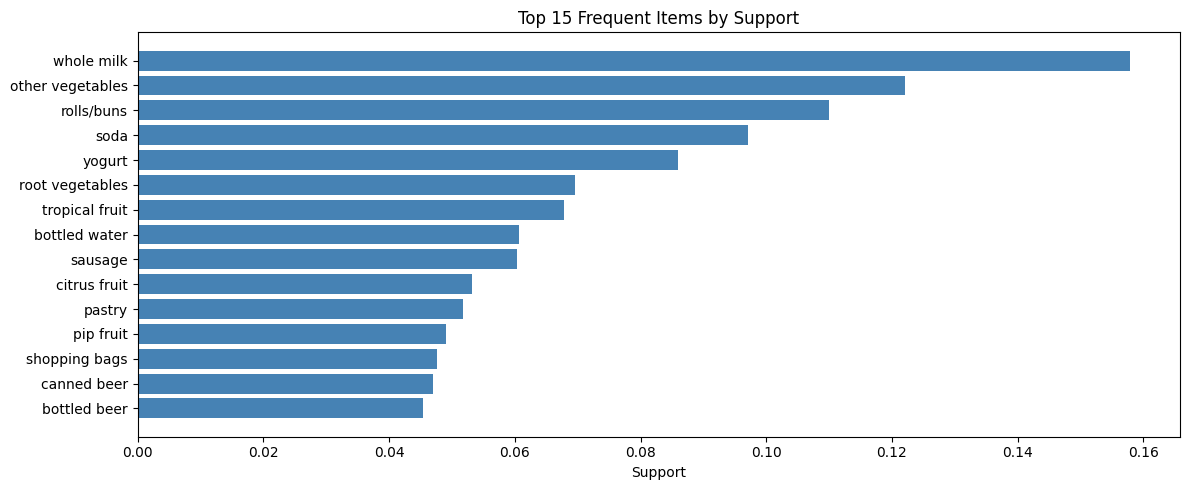

In [9]:
# Visualization 1: Bar chart of top frequent itemsets
top_items = frequent_itemsets[frequent_itemsets['length'] == 1].sort_values('support', ascending=False).head(15)
items_labels = [list(i)[0] for i in top_items['itemsets']]

plt.figure(figsize=(12, 5))
plt.barh(items_labels, top_items['support'].values, color='steelblue')
plt.xlabel('Support')
plt.title('Top 15 Frequent Items by Support')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

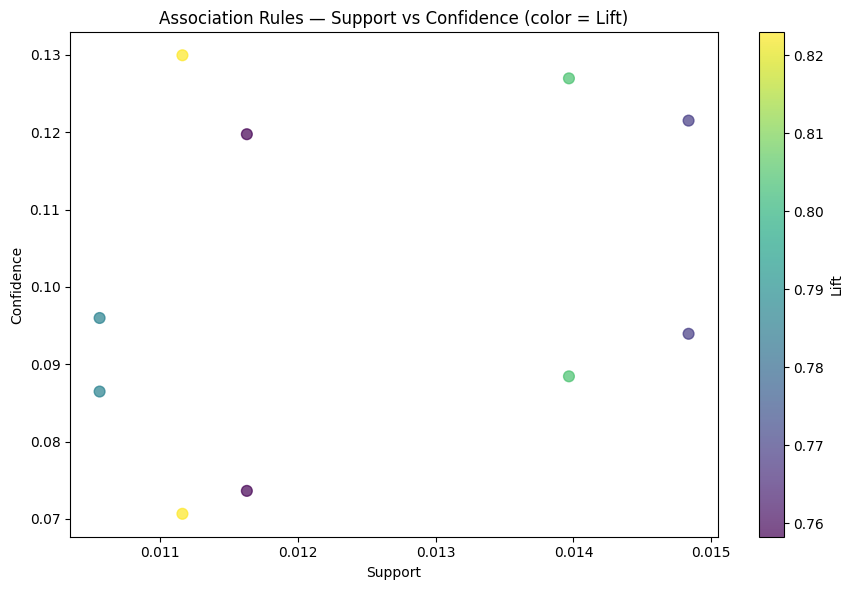

In [10]:
# Visualization 2: Support vs Confidence scatter plot (colored by Lift)
# FIX: Drop NaN rows before plotting so scatter is never empty
plot_rules = rules.dropna(subset=['support', 'confidence', 'lift'])

if len(plot_rules) == 0:
    print("No valid rules to plot — try lowering min_support or min_threshold.")
else:
    plt.figure(figsize=(9, 6))
    sc = plt.scatter(
        plot_rules['support'],
        plot_rules['confidence'],
        c=plot_rules['lift'],
        cmap='viridis',
        alpha=0.7,
        s=60
    )
    plt.colorbar(sc, label='Lift')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Association Rules — Support vs Confidence (color = Lift)')
    plt.tight_layout()
    plt.show()

---
## SCENARIO 2 — DIMENSIONALITY REDUCTION USING PCA
**Dataset:** Wine Dataset (sklearn built-in)

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

# Task 1: Load dataset
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name='Class')

print("Wine Dataset Shape:", X_wine.shape)
print("Classes:", wine.target_names)
print(X_wine.head())

Wine Dataset Shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  

In [12]:
# Task 2 & 3: Preprocessing — check missing values and standardize
print("Missing values:", X_wine.isnull().sum().sum())

scaler = StandardScaler()
X_scaled_wine = scaler.fit_transform(X_wine)
print("Features standardized. Shape:", X_scaled_wine.shape)

Missing values: 0
Features standardized. Shape: (178, 13)


In [13]:
# Task 4 & 5: Apply PCA — all components
pca_full = PCA()
pca_full.fit(X_scaled_wine)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance Ratio per component:")
for i, ev in enumerate(explained_variance, 1):
    print(f"  PC{i}: {ev:.4f} ({ev*100:.2f}%)")

Explained Variance Ratio per component:
  PC1: 0.3620 (36.20%)
  PC2: 0.1921 (19.21%)
  PC3: 0.1112 (11.12%)
  PC4: 0.0707 (7.07%)
  PC5: 0.0656 (6.56%)
  PC6: 0.0494 (4.94%)
  PC7: 0.0424 (4.24%)
  PC8: 0.0268 (2.68%)
  PC9: 0.0222 (2.22%)
  PC10: 0.0193 (1.93%)
  PC11: 0.0174 (1.74%)
  PC12: 0.0130 (1.30%)
  PC13: 0.0080 (0.80%)


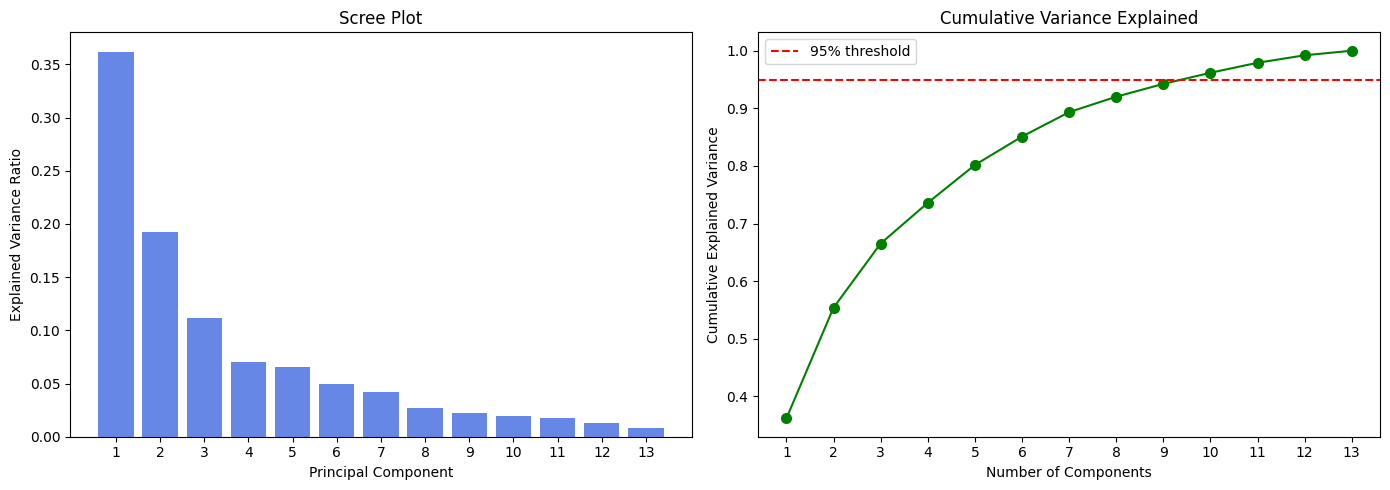

Components needed to explain 95% variance: 10


In [14]:
# Task 6: Scree Plot — Variance vs Components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_variance)+1), explained_variance, color='royalblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(explained_variance)+1))

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'go-', markersize=7)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(range(1, len(cumulative_variance)+1))
axes[1].legend()

plt.tight_layout()
plt.show()

# Components needed for 95% variance
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed to explain 95% variance: {n_95}")

In [15]:
# Task 7: Reduce to 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled_wine)

print("Original shape:", X_scaled_wine.shape)
print("Reduced (2D) shape:", X_pca_2d.shape)
print(f"Variance explained by 2 PCs: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

Original shape: (178, 13)
Reduced (2D) shape: (178, 2)
Variance explained by 2 PCs: 55.41%


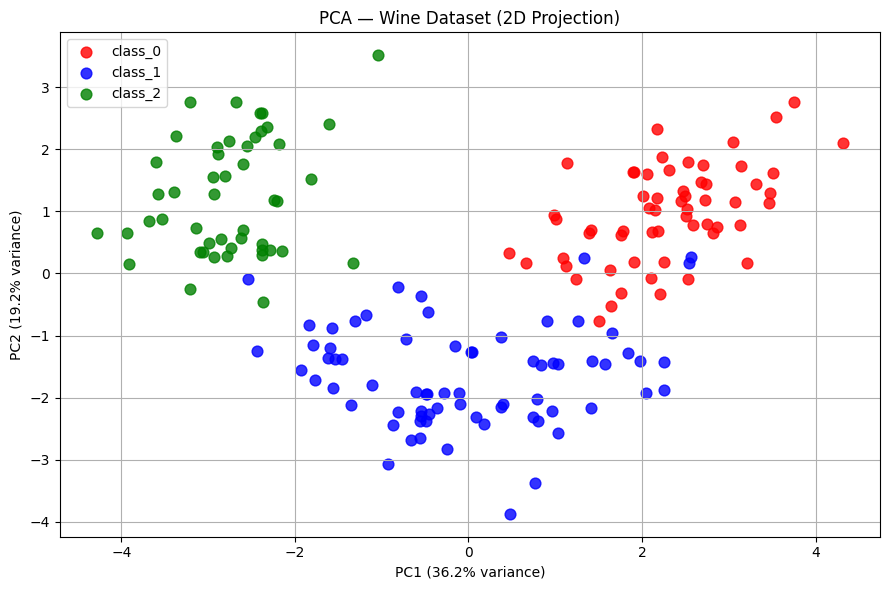

In [16]:
# Task 8: Visualize 2D PCA scatter plot
colors = ['red', 'blue', 'green']
plt.figure(figsize=(9, 6))

for class_id, class_name in enumerate(wine.target_names):
    mask = y_wine == class_id
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                color=colors[class_id], label=class_name, s=60, alpha=0.8)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA — Wine Dataset (2D Projection)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

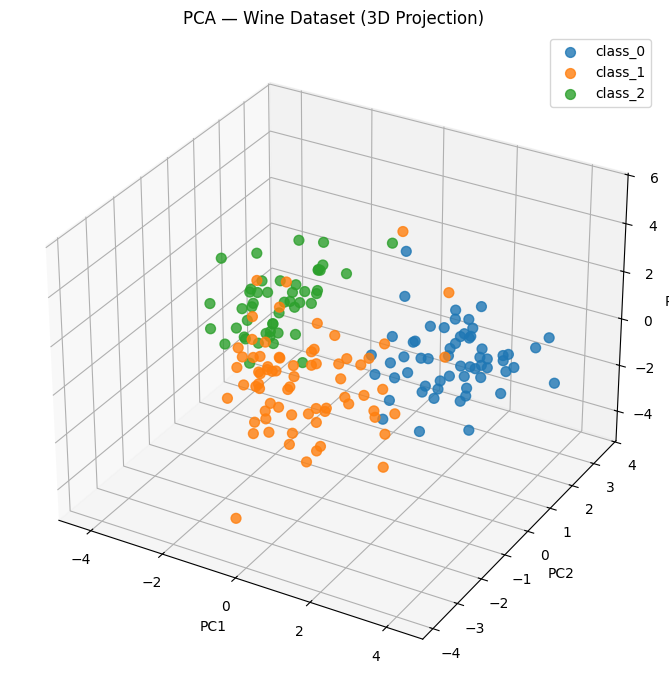

Variance explained by 3 PCs: 66.53%


In [17]:
# 3D PCA visualization
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled_wine)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for class_id, class_name in enumerate(wine.target_names):
    mask = y_wine == class_id
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               label=class_name, s=50, alpha=0.8)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA — Wine Dataset (3D Projection)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Variance explained by 3 PCs: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")